# Extrapolate end-to-end (intelligrate.extrapolate)

This notebook runs the full `intelligrate.extrapolate` workflow using the **Python API**:
1) nested CV training (OOF outputs)
2) full fit (final model artifact)
3) full predict (new samples + optional evaluation on paired subset)

Outputs are written to `results/`.

It uses the example data in `data/`.


## Install (pip)
If you are running this notebook outside the repo, install with pip.



In [1]:
from pathlib import Path
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pwd

'/Users/meyeanni/Desktop/git_sourdough/Intelligrate/docs/notebooks'

install intelligrate (if not yet installed):


In [8]:
# Uncomment if needed:
# !pip install "intelligrate @ git+https://github.com/ORG/REPO.git@vX.Y.Z"



In [3]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists():
            return p
    raise FileNotFoundError('Could not find repo root (pyproject.toml)')

repo_root = find_repo_root(Path.cwd())

# Ensure local package imports work without installation
sys.path.insert(0, str(repo_root / 'src'))

results_dir = repo_root / 'results/primates_ecs'
results_dir.mkdir(parents=True, exist_ok=True)

print('Repo root:', repo_root)
print('Results dir:', results_dir)


Repo root: /Users/meyeanni/Desktop/git_sourdough/Intelligrate
Results dir: /Users/meyeanni/Desktop/git_sourdough/Intelligrate/results/primates_ecs


## Load inputs
- `X_ASVs.tsv`: paired samples (ASVs)
- `X_ASVs_full.tsv`: all samples (paired + unpaired, for extrapolation)
- `Y_kos.tsv`: KO profiles for paired samples
- `ko_to_superclass.tsv`: KO -> pathway/superclass mapping, optional


In [88]:
X_full = pd.read_csv(repo_root / 'data/primates' / 'X_ASVs_full.tsv', sep='	', index_col=0)
X = pd.read_csv(repo_root / 'data/primates' / 'X_ASVs.tsv', sep='	', index_col=0)
Y = pd.read_csv(repo_root / 'data/primates' / 'Y_ecs.tsv', sep='	', index_col=0)

X_full = X_full.apply(pd.to_numeric, errors="coerce")
X = X.apply(pd.to_numeric, errors="coerce")
Y = Y.apply(pd.to_numeric, errors="coerce")

print('X_full:', X_full.shape)
print('X:', X.shape)
print('Y:', Y.shape)


X_full: (77, 8251)
X: (77, 8251)
Y: (77, 2468)


### Optional: Pre-filter Y before any modeling
If you want to pre-filter KO features (e.g., apply a detection threshold once globally and keep zeroes as informative), do it here **once** and then use `Y` everywhere downstream.
This avoids per-fold KO dropping, but it changes the modeling assumptions.

**Important:** if you do this, pass the filtered `Y` into all downstream calls (training, fixed-param sweep, evaluation, PICRUSt2 comparisons).


In [15]:
# --- Optional global Y pre-filtering (edit as needed) ---
# Example: apply a detect threshold once and keep zeros as zeros.
# This is global pre-filtering; be aware this uses all samples (no CV isolation).
# If you enable this, replace Y with Y_prefiltered and use it everywhere downstream.
#
# detect_threshold = model_cfg['y_detect_threshold']
# Y_prefiltered = Y.copy()
# Y_prefiltered = Y_prefiltered.mask(Y_prefiltered < detect_threshold, 0.0)
# Y = Y_prefiltered

# NOTE: After this point, make sure any call uses the updated Y:
# - train/_run_once or nested CV inputs
# - fixed_param_oof_knn_on_embedding
# - evaluate_paired_subset
# - PICRUSt2 comparisons (align to the same KO set as Y)


## Parameters
Parameters that we define here correspond to what can be found in the **defaults** as `configs/default.yaml`, but now we expose them here in the notebook for easier editing.


If you want to see every parameter and full explanations, also check:
- `docs/TUTORIAL_extrapolate.md`
- `src/intelligrate/extrapolate/train.py` and `src/intelligrate/extrapolate/cv_knn.py`


In [150]:
# ---- Data file names (used by the training API) ----
data_cfg = {
    'x_full': 'X_ASVs_full.tsv',
    'x': 'X_ASVs.tsv',
    'y': 'Y_ecs.tsv',
    'picrust2': 'picrust2_ecs.tsv', # optional for comparison
    #'ko_to_superclass':   # optional mapping file
}


# ---- Cross-validation settings ----
cv_cfg = {
    # outer_splits/inner_splits: more splits = slower but more stable estimates
    'outer_splits': 5,
    'inner_splits': 3,
    'seed': 0,
    # informed_splits: use metadata to form splits (False by default)
    'informed_splits': False,
}

# ---- X embedding (k-mer -> low-dim) ----
embed_cfg = {
    # min_prev_x_abs: drop k-mers present in fewer samples than this
    'min_prev_x_abs': 16,
    # pseudocount_x: added before CLR
    'pseudocount_x': 0.5,
    # n_components: SVD dimensions for the k-mer embedding (X space)
    'n_components': 16, #10
}

# ---- Model / prediction settings ----
model_cfg = {
    # min_prev_y_abs: drop KOs seen in fewer samples than this
    'min_prev_y_abs': 1,
    # y_detect_threshold: detection threshold in TSS space
    'y_detect_threshold': 1000.0,
    # pseudocount_y: added before CLR
    'pseudocount_y': 0.5 / 1e6,

    # KNN hyperparameters (grid for nested CV)
    'neigh_k_grid': [20, 24, 28, 32],
    'tau_mult_grid': [0.5, 1.0, 2.0, 4.0],
    'lam_grid': [0.0],
    'y_latent_k_grid': [0, 10, 20],

    # Metric learning
    'use_metric_learning': True,
    'metric_max_pairs': 5000,
    'metric_ridge_grid': [1.0, 2.5, 5.0],

    # Out-of-distribution shrinkage
    'ood_shrink': True,
    'ood_shrink_inner': True,
    'ood_lam_base': 0.7,
    'ood_lam_cap': 0.5,
    'ood_tau_inflate': False,
}

# ---- Objective weights ----
objective_cfg = {
    # w_dm is the primary objective (Aitchison DM Spearman)
    'w_dm': 1.0,
    'w_wclr': 0.0,
    'w_pw_rmse': 0.0,
    'w_softf1': 0.0,
    'w_jsd': 0.0,
}

# ---- Precision/recall settings ----
prf_cfg = {
    'prf_thresh': 1.0e-6,
    'prf_weight': 'binary', 
}

# ---- Optional metrics ----
metrics_cfg = {
    'compute_wclr': True,
    'compute_jsd': True, 
    'compute_pathway_rmse': False,
    'pathway_rmse_per_group': False,
    'pathway_rmse_log1p': False,
}

# ---- Score settings (for the optional global OOF DM check) ----
score_cfg = {
    'min_prev_y_abs': 1,
    'y_detect_threshold': 3000.0,
    'pseudocount_y': 0.5 / 1e6,
}


## 1) Train on paired-samples (nested CV)
We call the training API directly and then write the outputs to `results/`.

This step is to get out-of-fold (OOF) predictions for the paired samples, which can be used for initial model evaluation and calibration/hyperparameter tuning and selection.


In [151]:
from intelligrate.extrapolate import train as train_model

cfg = {
    'data': data_cfg,
    'cv': cv_cfg,
    'embed': embed_cfg,
    'model': model_cfg,
    'objective': objective_cfg,
    'prf': prf_cfg,
    'metrics': metrics_cfg,
    'score': score_cfg,
}

payload = train_model._run_once(cfg, data_dir=repo_root / 'data/primates', out_dir=results_dir)

# Write outputs (same files as the CLI)
oof_clr = payload['oof_clr']
oof_tss = payload['oof_tss']
folds = payload['folds']
run = payload['run']

# Save core outputs
(oof_clr).to_csv(results_dir / 'oof_clr.tsv', sep='	')
(oof_tss).to_csv(results_dir / 'oof_tss.tsv', sep='	')
folds.to_csv(results_dir / 'folds.tsv', sep='	', index=False)
(results_dir / 'summary.json').write_text(json.dumps(run, indent=2))

summary_flat = {k: v for k, v in run.items() if k != 'config'}
pd.DataFrame([summary_flat]).to_csv(results_dir / 'summary.tsv', sep='	', index=False)

print('OBJECTIVE_DM_SPEARMAN_MEAN:', run['objective_dm_spearman_mean'])
print('MODEL_DM_UNION_STRICT:', run['model_dm_union_strict'])


OBJECTIVE_DM_SPEARMAN_MEAN: 0.5455116762966628
MODEL_DM_UNION_STRICT: 0.8674177249575088


In [152]:
summary = json.loads((results_dir / 'summary.json').read_text())
summary_keys = [
    'objective_dm_spearman_mean',
    'model_dm_union_strict',
    'picrust2_dm_union_strict',
    'delta_union',
    'runtime_sec',
]

pd.DataFrame([{k: summary.get(k) for k in summary_keys}])


,objective_dm_spearman_mean,model_dm_union_strict,picrust2_dm_union_strict,delta_union,runtime_sec
0,0.545512,0.867418,0.887025,-0.019607,2.722137


  - objective_dm_spearman_mean: primary training objective, averaged Spearman correlation between true vs. predicted
  Aitchison distance matrices across CV folds (higher = better recovery of sample–sample structure).
  - model_dm_union_strict: KO‑union Spearman score on OOF predictions (union of KOs in truth and prediction, computed in CLR/
  Aitchison space; higher = better overall agreement).
  - picrust2_dm_union_strict: same KO‑union score for PICRUSt2 (baseline), optional (only if PICRUSt2 predictions are provided).
  - delta_union: model_dm_union_strict − picrust2_dm_union_strict (positive means the model beats PICRUSt2 in terms of matrix spearman correlations on the KO union).
  - runtime_sec: total training runtime in seconds.

In [153]:
folds = pd.read_csv(results_dir / 'folds.tsv', sep='	')
folds.head()

,fold,split_mode,kmeans_k_used,best_inner_comp,best_inner_dm,dm_spearman,wclr_mse,pw_rmse_log1p,soft_precision,soft_recall,...,shrink_lam_q90,std_dm_true,std_dm_pred,y_keep_n,neigh_k,tau_mult,lam,y_latent_k,metric_ridge,inner_dm
0,1,kfold,NaN,0.288764,0.381963,0.593958,0.540152,NaN,0.998340,0.999447,...,0.5,2.723536,0.933219,339,20,0.5,0.0,10,1.0,0.381963
1,2,kfold,NaN,0.296596,0.373916,0.591645,0.369413,NaN,0.996243,1.000000,...,0.5,1.922161,0.907520,366,28,0.5,0.0,10,1.0,0.373916
2,3,kfold,NaN,0.387875,0.407783,0.347045,0.495495,NaN,0.995028,1.000000,...,0.5,2.677005,0.541665,362,20,1.0,0.0,10,1.0,0.407783
3,4,kfold,NaN,0.349265,0.386322,0.579038,0.336744,NaN,0.996557,1.000000,...,0.5,2.280780,1.146003,368,24,0.5,0.0,10,1.0,0.386322
4,5,kfold,NaN,0.432587,0.525903,0.615872,0.150382,NaN,1.000000,1.000000,...,0.5,2.590838,1.301207,354,20,0.5,0.0,20,1.0,0.525903


-->> this contains all the 'best' parameter selections for paired sample predictions, which can be considered for evaluation and calibration/hyperparameter tuning and selection.


In [154]:
#how many rows in oof_tss contain any nans?:
oof_tss.isna().any(axis=1).sum()

np.int64(77)

-> all these nans need to be addressed in the evaluations further below

### Optional: fixed-parameter sweep for stable hyperparameters

Use this to find a **single fixed hyperparameter set** that performs well for leakage-free OOF.
It evaluates each combo with fixed-parameter OOF and ranks by `dm_union_strict`.

**Important:** if a parameter is *not* listed in `fixed_param_sweep`, the sweep will use the value
from config. For parameters with a `*_grid` (e.g., `neigh_k_grid`), it will use that grid list.
To force a single value, list it explicitly in `fixed_param_sweep`.


for (otpional) pathway evaluation later on, we import also the KO -> pathway mapping:

In [72]:
#make a dictionary out of ko to superclass mapping:
# ko_to_superclass_path = repo_root / 'data/primates_ecs' / 'ko_to_superclass.tsv'
# ko_to_superclass_df = pd.read_csv(ko_to_superclass_path, sep='	', index_col=0)
# ko_to_superclass = ko_to_superclass_df['superclass'].to_dict()
# ko_to_superclass

{'K00001': 'SCFA fermentation',
 'K00002': 'Cofactors/vitamins',
 'K00003': 'Energy/central carbon',
 'K00004': 'Energy/central carbon',
 'K00005': 'Energy/central carbon',
 'K00008': 'Energy/central carbon',
 'K00009': 'Energy/central carbon',
 'K00010': 'Energy/central carbon',
 'K00012': 'Carbohydrate metabolism',
 'K00013': 'Energy/central carbon',
 'K00014': 'Tryptophan metabolism',
 'K00015': 'Energy/central carbon',
 'K00016': 'SCFA fermentation',
 'K00018': 'Energy/central carbon',
 'K00019': 'Other',
 'K00020': 'Energy/central carbon',
 'K00024': 'Energy/central carbon',
 'K00026': 'Energy/central carbon',
 'K00027': 'Energy/central carbon',
 'K00029': 'Energy/central carbon',
 'K00030': 'Cofactors/vitamins',
 'K00031': 'Other',
 'K00032': 'Energy/central carbon',
 'K00033': 'Energy/central carbon',
 'K00034': 'Energy/central carbon',
 'K00036': 'Energy/central carbon',
 'K00038': 'Energy/central carbon',
 'K00040': 'Energy/central carbon',
 'K00041': 'Energy/central carbon',


In [20]:
embed_cfg

{'min_prev_x_abs': 3, 'pseudocount_x': 0.5, 'n_components': 16}

In [155]:
from intelligrate.extrapolate.embedding import fit_x_embedding_svd_clr
from intelligrate.extrapolate.fixed_param_sweep import run_fixed_param_sweep_explicit

# Fit embedding on all samples (X_full)
embed = fit_x_embedding_svd_clr(
    X_full,
    min_prev_x_abs=int(embed_cfg['min_prev_x_abs']),
    pseudocount_x=float(embed_cfg['pseudocount_x']),
    n_components=int(embed_cfg['n_components']),
    seed=int(cv_cfg['seed']),
)

embed_path = results_dir / 'embed.joblib'
joblib.dump(embed, embed_path)
print('Saved embedding to:', embed_path)

# Define a small fixed-parameter sweep (uses the same X_full/X/Y/ko_to_superclass as above)
cfg["fixed_param_sweep"] = {
    "neigh_k": [18, 20, 22],
    "tau_mult": [0.5, 1.0],
    "y_latent_k": [5, 10, 15],
    "metric_ridge": [1.0, 2.5],
}

sweep_out = results_dir / "fixed_param_sweep.tsv"
sweep_df = run_fixed_param_sweep_explicit(
    X_full=X_full,
    X=X,
    Y=Y,
    ko_to_superclass=None,
    out_path=sweep_out,
    cv_cfg=cv_cfg,
    embed_cfg=embed_cfg,
    model_cfg=model_cfg,
    prf_cfg=prf_cfg,
    metrics_cfg=metrics_cfg,
    sweep_cfg=cfg["fixed_param_sweep"],
    embed=embed,
    
)
sweep_df.head()


Saved embedding to: /Users/meyeanni/Desktop/git_sourdough/Intelligrate/results/primates_ecs/embed.joblib


,neigh_k,tau_mult,y_latent_k,metric_ridge,lam,min_prev_y_abs,y_detect_threshold,pseudocount_y,metric_max_pairs,tau_scale_k_nn,...,ood_lam_cap,ood_tau_inflate,ood_tau_gamma,use_metric_learning,outer_splits,seed,informed_splits,dm_union_strict,dm_union_raw,runtime_s
4,18,0.5,15,1.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.870624,0.103938,0.597704
5,18,0.5,15,2.5,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.870624,0.103938,0.601531
17,20,0.5,15,2.5,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.869978,0.103737,0.567679
16,20,0.5,15,1.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.869978,0.103737,0.571233
29,22,0.5,15,2.5,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.869900,0.103472,0.568207


In [156]:
#check which sweep params give the best dm_union_strict:
sweep_df.sort_values('dm_union_raw', ascending=False).head()

,neigh_k,tau_mult,y_latent_k,metric_ridge,lam,min_prev_y_abs,y_detect_threshold,pseudocount_y,metric_max_pairs,tau_scale_k_nn,...,ood_lam_cap,ood_tau_inflate,ood_tau_gamma,use_metric_learning,outer_splits,seed,informed_splits,dm_union_strict,dm_union_raw,runtime_s
4,18,0.5,15,1.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.870624,0.103938,0.597704
5,18,0.5,15,2.5,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.870624,0.103938,0.601531
17,20,0.5,15,2.5,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.869978,0.103737,0.567679
16,20,0.5,15,1.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.869978,0.103737,0.571233
29,22,0.5,15,2.5,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.869900,0.103472,0.568207


-> in this case the best config is neight_k = 28, tau_mult = 0.5, y_latent_k = 20, metric_ridge = 2.5

### now if you want to try a few more fixed parameter combos, go ahead, otherwise skip and continue with the full fit of the final model further down

In [157]:
# Define a small fixed-parameter sweep (uses the same X_full/X/Y/ko_to_superclass as above), round 2:
cfg["fixed_param_sweep"] = {
    "neigh_k": [5, 10, 12, 18],
    "tau_mult": [0.35, 0.5, 0.65],
    "y_latent_k": [13, 15, 17],
    "metric_ridge": [1],
}

sweep_out2 = results_dir / "fixed_param_sweep2.tsv"
sweep_df2 = run_fixed_param_sweep_explicit(
    X_full=X_full,
    X=X,
    Y=Y,
    ko_to_superclass=None,
    out_path=sweep_out,
    cv_cfg=cv_cfg,
    embed_cfg=embed_cfg,
    model_cfg=model_cfg,
    prf_cfg=prf_cfg,
    metrics_cfg=metrics_cfg,
    sweep_cfg=cfg["fixed_param_sweep"],
    embed=embed,
)
sweep_df2.head()

,neigh_k,tau_mult,y_latent_k,metric_ridge,lam,min_prev_y_abs,y_detect_threshold,pseudocount_y,metric_max_pairs,tau_scale_k_nn,...,ood_lam_cap,ood_tau_inflate,ood_tau_gamma,use_metric_learning,outer_splits,seed,informed_splits,dm_union_strict,dm_union_raw,runtime_s
1,5,0.35,15,1.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.880261,0.107078,0.628664
2,5,0.35,17,1.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.879119,0.106700,0.609227
29,18,0.35,17,1.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.879021,0.106334,0.559960
28,18,0.35,15,1.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.878427,0.106709,0.570536
11,10,0.35,17,1.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.878365,0.106774,0.674621


In [160]:
sweep_df2.sort_values('dm_union_raw', ascending=False).head()

,neigh_k,tau_mult,y_latent_k,metric_ridge,lam,min_prev_y_abs,y_detect_threshold,pseudocount_y,metric_max_pairs,tau_scale_k_nn,...,ood_lam_cap,ood_tau_inflate,ood_tau_gamma,use_metric_learning,outer_splits,seed,informed_splits,dm_union_strict,dm_union_raw,runtime_s
10,10,0.35,15,1.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.878335,0.107173,0.595005
9,10,0.35,13,1.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.877399,0.107098,0.594906
1,5,0.35,15,1.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.880261,0.107078,0.628664
0,5,0.35,13,1.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.877507,0.106975,0.660702
19,12,0.35,15,1.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.878356,0.106953,0.563300


In [161]:
# Define a small fixed-parameter sweep (uses the same X_full/X/Y/ko_to_superclass as above), round 3: keep best ones, sweep y_latent_k
cfg["fixed_param_sweep"] = {
    "neigh_k": [3, 4, 5, 6],
    "tau_mult": [0.1, 0.25, 0.35, 0.5],
    "y_latent_k": [15],
    "metric_ridge": [1, 2.5, 5],
    
}

sweep_out3 = results_dir / "fixed_param_sweep3.tsv"
sweep_df3 = run_fixed_param_sweep_explicit(
    X_full=X_full,
    X=X,
    Y=Y,
    ko_to_superclass=None,
    out_path=sweep_out,
    cv_cfg=cv_cfg,
    embed_cfg=embed_cfg,
    model_cfg=model_cfg,
    prf_cfg=prf_cfg,
    metrics_cfg=metrics_cfg,
    sweep_cfg=cfg["fixed_param_sweep"],
    embed=embed,
)
sweep_df3.head()

,neigh_k,tau_mult,y_latent_k,metric_ridge,lam,min_prev_y_abs,y_detect_threshold,pseudocount_y,metric_max_pairs,tau_scale_k_nn,...,ood_lam_cap,ood_tau_inflate,ood_tau_gamma,use_metric_learning,outer_splits,seed,informed_splits,dm_union_strict,dm_union_raw,runtime_s
29,5,0.25,15,5.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.883459,0.105794,0.571924
28,5,0.25,15,2.5,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.883459,0.105794,0.562789
27,5,0.25,15,1.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.883459,0.105794,0.565688
41,6,0.25,15,5.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.883329,0.105893,0.570084
40,6,0.25,15,2.5,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.883329,0.105893,0.566765


In [163]:
sweep_df3.sort_values('dm_union_strict', ascending=False).head()

,neigh_k,tau_mult,y_latent_k,metric_ridge,lam,min_prev_y_abs,y_detect_threshold,pseudocount_y,metric_max_pairs,tau_scale_k_nn,...,ood_lam_cap,ood_tau_inflate,ood_tau_gamma,use_metric_learning,outer_splits,seed,informed_splits,dm_union_strict,dm_union_raw,runtime_s
29,5,0.25,15,5.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.883459,0.105794,0.571924
27,5,0.25,15,1.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.883459,0.105794,0.565688
28,5,0.25,15,2.5,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.883459,0.105794,0.562789
41,6,0.25,15,5.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.883329,0.105893,0.570084
39,6,0.25,15,1.0,0.0,1,1000.0,5.000000e-07,5000,10,...,0.5,False,1.0,True,5,0,False,0.883329,0.105893,0.570246


In [164]:
# Define a small fixed-parameter sweep (uses the same X_full/X/Y/ko_to_superclass as above), round 4: keep best one, sweep y_detect_threshold
cfg["fixed_param_sweep"] = {
    "neigh_k": [5],
    "tau_mult": [0.25],
    "y_latent_k": [15],
    "metric_ridge": [1],
    "min_prev_y_abs": [0, 1, 3, 5, 10],
    "y_detect_threshold": [0, 100.0, 500.0, 1000.0, 1500.0, 2000.0],
    "metric_max_pairs": [3000],
}

sweep_out4 = results_dir / "fixed_param_sweep4.tsv"
sweep_df4 = run_fixed_param_sweep_explicit(
    X_full=X_full,
    X=X,
    Y=Y,
    ko_to_superclass=None,
    out_path=sweep_out,
    cv_cfg=cv_cfg,
    embed_cfg=embed_cfg,
    model_cfg=model_cfg,
    prf_cfg=prf_cfg,
    metrics_cfg=metrics_cfg,
    sweep_cfg=cfg["fixed_param_sweep"],
    embed=embed,
)
sweep_df4.head()

,neigh_k,tau_mult,y_latent_k,metric_ridge,lam,min_prev_y_abs,y_detect_threshold,pseudocount_y,metric_max_pairs,tau_scale_k_nn,...,ood_lam_cap,ood_tau_inflate,ood_tau_gamma,use_metric_learning,outer_splits,seed,informed_splits,dm_union_strict,dm_union_raw,runtime_s
5,5,0.25,15,1.0,0.0,0,2000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.931120,0.558163,0.934590
4,5,0.25,15,1.0,0.0,0,1500.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.929755,0.558163,1.031572
3,5,0.25,15,1.0,0.0,0,1000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.929417,0.558163,0.912536
9,5,0.25,15,1.0,0.0,1,1000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.883459,0.105794,0.575686
8,5,0.25,15,1.0,0.0,1,500.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.874613,0.112960,0.603155


In [166]:
sweep_df4.sort_values('dm_union_strict', ascending=False).head()

,neigh_k,tau_mult,y_latent_k,metric_ridge,lam,min_prev_y_abs,y_detect_threshold,pseudocount_y,metric_max_pairs,tau_scale_k_nn,...,ood_lam_cap,ood_tau_inflate,ood_tau_gamma,use_metric_learning,outer_splits,seed,informed_splits,dm_union_strict,dm_union_raw,runtime_s
5,5,0.25,15,1.0,0.0,0,2000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.931120,0.558163,0.934590
4,5,0.25,15,1.0,0.0,0,1500.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.929755,0.558163,1.031572
3,5,0.25,15,1.0,0.0,0,1000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.929417,0.558163,0.912536
9,5,0.25,15,1.0,0.0,1,1000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.883459,0.105794,0.575686
8,5,0.25,15,1.0,0.0,1,500.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.874613,0.112960,0.603155


In [167]:
cfg["fixed_param_sweep"] = {
    "neigh_k": [5],
    "tau_mult": [0.25],
    "y_latent_k": [15],
    "metric_ridge": [1],
    "min_prev_y_abs": [0],
    "y_detect_threshold": [2000, 2500, 3000],
    "metric_max_pairs": [3000],
}

sweep_out4x = results_dir / "fixed_param_sweep4.tsv"
sweep_df4x = run_fixed_param_sweep_explicit(
    X_full=X_full,
    X=X,
    Y=Y,
    ko_to_superclass=None,
    out_path=sweep_out,
    cv_cfg=cv_cfg,
    embed_cfg=embed_cfg,
    model_cfg=model_cfg,
    prf_cfg=prf_cfg,
    metrics_cfg=metrics_cfg,
    sweep_cfg=cfg["fixed_param_sweep"],
    embed=embed,
)
sweep_df4x.head()

,neigh_k,tau_mult,y_latent_k,metric_ridge,lam,min_prev_y_abs,y_detect_threshold,pseudocount_y,metric_max_pairs,tau_scale_k_nn,...,ood_lam_cap,ood_tau_inflate,ood_tau_gamma,use_metric_learning,outer_splits,seed,informed_splits,dm_union_strict,dm_union_raw,runtime_s
0,5,0.25,15,1.0,0.0,0,2000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.931120,0.558163,1.011447
1,5,0.25,15,1.0,0.0,0,2500.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.902276,0.558163,0.981213
2,5,0.25,15,1.0,0.0,0,3000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.857213,0.558163,0.915398


In [168]:
sweep_df4x.sort_values('dm_union_raw', ascending=False).head()

,neigh_k,tau_mult,y_latent_k,metric_ridge,lam,min_prev_y_abs,y_detect_threshold,pseudocount_y,metric_max_pairs,tau_scale_k_nn,...,ood_lam_cap,ood_tau_inflate,ood_tau_gamma,use_metric_learning,outer_splits,seed,informed_splits,dm_union_strict,dm_union_raw,runtime_s
0,5,0.25,15,1.0,0.0,0,2000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.931120,0.558163,1.011447
1,5,0.25,15,1.0,0.0,0,2500.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.902276,0.558163,0.981213
2,5,0.25,15,1.0,0.0,0,3000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.857213,0.558163,0.915398


In [169]:
# Define a small fixed-parameter sweep (uses the same X_full/X/Y/ko_to_superclass as above), round 4: keep best one, sweep y_detect_threshold
cfg["fixed_param_sweep"] = {
    "neigh_k": [5],
    "tau_mult": [0.25],
    "y_latent_k": [15],
    "metric_ridge": [1],
    "min_prev_y_abs": [0],
    "y_detect_threshold": [2000],
    "metric_max_pairs": [3000],
    "lam": [0.0, 0.1, 0.2, 0.5, 1],
}

sweep_out5 = results_dir / "fixed_param_sweep5.tsv"
sweep_df5 = run_fixed_param_sweep_explicit(
    X_full=X_full,
    X=X,
    Y=Y,
    ko_to_superclass=None,
    out_path=sweep_out,
    cv_cfg=cv_cfg,
    embed_cfg=embed_cfg,
    model_cfg=model_cfg,
    prf_cfg=prf_cfg,
    metrics_cfg=metrics_cfg,
    sweep_cfg=cfg["fixed_param_sweep"],
    embed=embed,
)
sweep_df5.head()

,neigh_k,tau_mult,y_latent_k,metric_ridge,lam,min_prev_y_abs,y_detect_threshold,pseudocount_y,metric_max_pairs,tau_scale_k_nn,...,ood_lam_cap,ood_tau_inflate,ood_tau_gamma,use_metric_learning,outer_splits,seed,informed_splits,dm_union_strict,dm_union_raw,runtime_s
0,5,0.25,15,1.0,0.0,0,2000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.931120,0.558163,0.952496
1,5,0.25,15,1.0,0.1,0,2000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.928905,0.558035,0.925228
2,5,0.25,15,1.0,0.2,0,2000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.924951,0.557748,0.896852
3,5,0.25,15,1.0,0.5,0,2000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.905051,0.553096,0.873544
4,5,0.25,15,1.0,1.0,0,2000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.890019,0.048068,0.854478


In [170]:
sweep_df5.sort_values('dm_union_strict', ascending=False).head()

,neigh_k,tau_mult,y_latent_k,metric_ridge,lam,min_prev_y_abs,y_detect_threshold,pseudocount_y,metric_max_pairs,tau_scale_k_nn,...,ood_lam_cap,ood_tau_inflate,ood_tau_gamma,use_metric_learning,outer_splits,seed,informed_splits,dm_union_strict,dm_union_raw,runtime_s
0,5,0.25,15,1.0,0.0,0,2000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.931120,0.558163,0.952496
1,5,0.25,15,1.0,0.1,0,2000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.928905,0.558035,0.925228
2,5,0.25,15,1.0,0.2,0,2000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.924951,0.557748,0.896852
3,5,0.25,15,1.0,0.5,0,2000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.905051,0.553096,0.873544
4,5,0.25,15,1.0,1.0,0,2000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.890019,0.048068,0.854478


In [171]:
# Define a small fixed-parameter sweep (uses the same X_full/X/Y/ko_to_superclass as above), round 4: keep best one, sweep y_detect_threshold
cfg["fixed_param_sweep"] = {
    "neigh_k": [5],
    "tau_mult": [0.25],
    "y_latent_k": [15],
    "metric_ridge": [1],
    "min_prev_y_abs": [0],
    "y_detect_threshold": [2000],
    "metric_max_pairs": [3000],
    "lam": [0.0],   
    
}

sweep_out6 = results_dir / "fixed_param_sweep6.tsv"
sweep_df6 = run_fixed_param_sweep_explicit(
    X_full=X_full,
    X=X,
    Y=Y,
    ko_to_superclass=None,
    out_path=sweep_out,
    cv_cfg=cv_cfg,
    embed_cfg=embed_cfg,
    model_cfg=model_cfg,
    prf_cfg=prf_cfg,
    metrics_cfg=metrics_cfg,
    sweep_cfg=cfg["fixed_param_sweep"],
    embed=embed,
)
sweep_df6.head()

,neigh_k,tau_mult,y_latent_k,metric_ridge,lam,min_prev_y_abs,y_detect_threshold,pseudocount_y,metric_max_pairs,tau_scale_k_nn,...,ood_lam_cap,ood_tau_inflate,ood_tau_gamma,use_metric_learning,outer_splits,seed,informed_splits,dm_union_strict,dm_union_raw,runtime_s
0,5,0.25,15,1.0,0.0,0,2000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.93112,0.558163,0.977465


In [172]:
sweep_df6.sort_values('dm_union_strict', ascending=False).head()

,neigh_k,tau_mult,y_latent_k,metric_ridge,lam,min_prev_y_abs,y_detect_threshold,pseudocount_y,metric_max_pairs,tau_scale_k_nn,...,ood_lam_cap,ood_tau_inflate,ood_tau_gamma,use_metric_learning,outer_splits,seed,informed_splits,dm_union_strict,dm_union_raw,runtime_s
0,5,0.25,15,1.0,0.0,0,2000.0,5.000000e-07,3000,10,...,0.5,False,1.0,True,5,0,False,0.93112,0.558163,0.977465


-> that's the final choice for now (sweep_df6)!

## 2) Full fit (final model)
We fit the embedding on all k-mer samples (same as before, but now parameters are exposed in case we would still want to update/improve some based on previous grid scans), then fit a final model on paired samples.

To pick hyperparameters, we take the most common (mode) values from the CV folds.
You can also set them manually.


### option 1 to get the best params from fits without sweep:

In [173]:

from intelligrate.extrapolate.full_fit import fit_final_model, save_model



# Choose final hyperparameters from folds (mode) -> the ones that were most often selected
def mode_or_first(series, default):
    if series is None or series.empty:
        return default
    return series.mode().iloc[0]

neigh_k = int(mode_or_first(folds.get('neigh_k'), model_cfg['neigh_k_grid'][0]))
tau_mult = float(mode_or_first(folds.get('tau_mult'), model_cfg['tau_mult_grid'][0]))
lam = float(mode_or_first(folds.get('lam'), model_cfg['lam_grid'][0]))
y_latent_k = int(mode_or_first(folds.get('y_latent_k'), model_cfg['y_latent_k_grid'][0]))
metric_ridge = float(mode_or_first(folds.get('metric_ridge'), model_cfg['metric_ridge_grid'][0]))

print('Selected hyperparameters:', neigh_k, tau_mult, lam, y_latent_k, metric_ridge)

Selected hyperparameters: 20 0.5 0.0 10 1.0


### option 2 to get the best params from fixed param sweep (which we will do now!)

In [174]:
from intelligrate.extrapolate.full_fit import fit_final_model, save_model

#which sweep_df should be considered? adapt here
sweep_final = sweep_df6.copy()

# Choose final hyperparameters from folds (mode) -> the ones that were most often selected
def mode_or_first(series, default):
    if series is None or series.empty:
        return default
    return series.mode().iloc[0]

neigh_k = int(mode_or_first(sweep_final.get('neigh_k'), model_cfg['neigh_k_grid'][0]))
tau_mult = float(mode_or_first(sweep_final.get('tau_mult'), model_cfg['tau_mult_grid'][0]))
lam = float(mode_or_first(sweep_final.get('lam'), model_cfg['lam_grid'][0]))
y_latent_k = int(mode_or_first(sweep_final.get('y_latent_k'), model_cfg['y_latent_k_grid'][0]))
metric_ridge = float(mode_or_first(sweep_final.get('metric_ridge'), model_cfg['metric_ridge_grid'][0]))
min_prev_y_abs = int(mode_or_first(sweep_final.get('min_prev_y_abs'), model_cfg['min_prev_y_abs']))
y_detect_threshold = float(mode_or_first(sweep_final.get('y_detect_threshold'), model_cfg['y_detect_threshold']))
metric_max_pairs = int(mode_or_first(sweep_final.get('metric_max_pairs'), model_cfg['metric_max_pairs']))

print('Selected hyperparameters:', neigh_k, tau_mult, lam, y_latent_k, metric_ridge, min_prev_y_abs, y_detect_threshold, metric_max_pairs)

Selected hyperparameters: 5 0.25 0.0 15 1.0 0 2000.0 3000


then, we fit the final model which we will then apply for extrapolation.

In [175]:
model = fit_final_model(
    X_train=X,
    Y_train_tpm=Y,
    embed=embed,
    min_prev_y_abs=min_prev_y_abs,
    y_detect_threshold=y_detect_threshold,
    pseudocount_y=float(model_cfg['pseudocount_y']),
    neigh_k=neigh_k,
    tau_mult=tau_mult,
    lam=lam,
    y_latent_k=y_latent_k,
    use_metric_learning=bool(model_cfg['use_metric_learning']),
    metric_ridge=metric_ridge,
    metric_max_pairs=metric_max_pairs,
    tau_scale_k_nn=int(model_cfg.get('tau_scale_k_nn', 10)),
    ood_shrink=bool(model_cfg.get('ood_shrink', False)),
    ood_lam_base=float(model_cfg.get('ood_lam_base', 0.1)),
    ood_lam_cap=float(model_cfg.get('ood_lam_cap', 0.8)),
    seed=int(cv_cfg['seed']),
)

model_path = save_model(model, results_dir / 'model.joblib')
print('Saved model to:', model_path)

Saved model to: /Users/meyeanni/Desktop/git_sourdough/Intelligrate/results/primates_ecs/model.joblib


## 3) Full predict (= extrapolate)
We predict for all samples, then (optionally) evaluate on the paired subset if truth is available.


In [176]:
from intelligrate.extrapolate.full_predict import predict_final_model, evaluate_paired_subset

# Predict for all samples (deployment)
Yhat_clr, Yhat_tss, diag = predict_final_model(X_full, model)

# We will save only the leakage-free version after replacing paired rows.


## Leakage-free paired predictions (fixed-parameter OOF)
We re-predict paired samples using fixed hyperparameters, training only on other samples.
Set outer_splits = N to emulate leave-one-out.


In [177]:
from intelligrate.extrapolate.cv_knn import fixed_param_oof_knn_on_embedding

oof_fixed_clr, oof_fixed_tss, oof_fixed_folds = fixed_param_oof_knn_on_embedding(
    X=X,
    Y_tpm=Y,
    embed=embed,
    ko_to_superclass=None,
    outer_splits=5,  # set to len(X) for leave-one-out
    seed=int(cv_cfg['seed']),
    min_prev_y_abs=min_prev_y_abs,
    y_detect_threshold=y_detect_threshold,
    pseudocount_y=float(model_cfg['pseudocount_y']),
    neigh_k=int(neigh_k),
    tau_mult=float(tau_mult),
    lam=float(lam),
    y_latent_k=int(y_latent_k),
    use_metric_learning=bool(model_cfg['use_metric_learning']),
    metric_max_pairs=metric_max_pairs,
    metric_ridge=float(metric_ridge),
    tau_scale_k_nn=int(model_cfg.get('tau_scale_k_nn', 10)),
    ood_shrink=bool(model_cfg.get('ood_shrink', False)),
    ood_lam_base=float(model_cfg.get('ood_lam_base', 0.1)),
    ood_lam_cap=float(model_cfg.get('ood_lam_cap', 0.8)),
    ood_tau_inflate=bool(model_cfg.get('ood_tau_inflate', False)),
    ood_tau_gamma=float(model_cfg.get('ood_tau_gamma', 1.0)),
    informed_splits=bool(cv_cfg.get('informed_splits', False)),
    informed_kmeans_on='X',
    prf_thresh=float(prf_cfg['prf_thresh']),
    prf_weight=str(prf_cfg['prf_weight']),
)

#drop columns if they are all nan or all 0:
oof_fixed_clr = oof_fixed_clr.loc[:, (oof_fixed_clr.notna().any()) & (oof_fixed_clr.sum(axis=0) != 0)]
oof_fixed_tss = oof_fixed_tss.loc[:, (oof_fixed_tss.notna().any()) & (oof_fixed_tss.sum(axis=0) != 0)]


oof_fixed_clr.to_csv(results_dir / 'oof_fixed_clr.tsv', sep='	')
oof_fixed_tss.to_csv(results_dir / 'oof_fixed_tss.tsv', sep='	')
oof_fixed_folds.to_csv(results_dir / 'oof_fixed_folds.tsv', sep='	', index=False)

# Replace paired rows in full predictions with leakage-free OOF predictions
# pred_full.* uses full-fit predictions for unpaired samples, but paired rows are OOF (leakage-free).
Yhat_clr_full_oof = Yhat_clr.copy()
Yhat_tss_full_oof = Yhat_tss.copy()
# Yhat_clr_full_oof.loc[X.index] = oof_fixed_clr.loc[X.index]
# Yhat_tss_full_oof.loc[X.index] = oof_fixed_tss.loc[X.index]
 # Align columns to full prediction columns
oof_fixed_clr_aligned = oof_fixed_clr.reindex(columns=Yhat_clr_full_oof.columns)
oof_fixed_tss_aligned = oof_fixed_tss.reindex(columns=Yhat_tss_full_oof.columns)

if oof_fixed_clr_aligned.isna().any().sum() > 0:
  oof_fixed_clr_aligned = oof_fixed_clr_aligned.fillna(0.0)
if oof_fixed_tss_aligned.isna().any().sum() > 0:
    oof_fixed_tss_aligned = oof_fixed_tss_aligned.fillna(0.0)

Yhat_clr_full_oof.loc[X.index] = oof_fixed_clr_aligned.loc[X.index]
Yhat_tss_full_oof.loc[X.index] = oof_fixed_tss_aligned.loc[X.index]

pred_full_prefix = results_dir / 'pred_full'
Yhat_clr_full_oof.to_csv(pred_full_prefix.with_suffix('.clr.tsv'), sep='	')
Yhat_tss_full_oof.to_csv(pred_full_prefix.with_suffix('.tss.tsv'), sep='	')

# Evaluate leakage-free paired predictions
metrics_oof = evaluate_paired_subset(
    truth_tpm=Y,
    pred_tss=oof_fixed_tss,
    pseudocount=float(model_cfg['pseudocount_y']),
    detect_threshold=y_detect_threshold,
    prf_thresh=float(prf_cfg['prf_thresh']),
    prf_weight=str(prf_cfg['prf_weight']),
    compute_wclr=bool(metrics_cfg['compute_wclr']),
    compute_jsd=bool(metrics_cfg['compute_jsd']),
    compute_pathway=bool(metrics_cfg['compute_pathway_rmse']),
    compute_per_pathway=bool(metrics_cfg['pathway_rmse_per_group']),
    ko_to_group=None,
    log1p_pathway=bool(metrics_cfg['pathway_rmse_log1p']),
    compute_null=True,
    null_n=50, #decrease for speed, increase for stability
    null_seed=0,
    null_mean_noise_scale=0.0001,
)

pd.DataFrame([metrics_oof]).to_csv(results_dir / 'pred_paired_oof.metrics.tsv', sep='	', index=False)
metrics_oof


{'dm_union_raw': 0.5581634896011032,
 'dm_union_strict': 0.9311199139570204,
 'bray_union_raw': 0.4876324883467098,
 'bray_union_strict': 0.8727963177383278,
 'procrustes_aitchison_raw': 0.6185972665218447,
 'procrustes_aitchison_strict': 0.7868432215084951,
 'procrustes_bray_raw': 0.5679158050185894,
 'procrustes_bray_strict': 0.7556779640618889,
 'dm_spearman': 0.9311199139570204,
 'bray_spearman': 0.8727963177383278,
 'procrustes_aitchison': 0.7868432215084951,
 'procrustes_bray': 0.7556779640618889,
 'soft_precision': 0.8785395136375134,
 'soft_recall': 0.8652989453366536,
 'soft_f1': 0.8644746290311065,
 'wclr_mse': 5.823663742669912,
 'jsd': 0.060684986985504875,
 'dm_spearman_union_raw': 0.5581634896011032,
 'bray_spearman_union_raw': 0.4876324883467098,
 'procrustes_aitchison_union_raw': 0.6185972665218447,
 'procrustes_bray_union_raw': 0.5679158050185894,
 'soft_precision_union_raw': 0.8454720351676891,
 'soft_recall_union_raw': 0.9646335735143361,
 'soft_f1_union_raw': 0.8997

### KO predictability score (per-KO confidence)
This combines conditional neighbor dispersion (lower is better) with per‑KO OOF Spearman (higher is better).

In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from intelligrate.extrapolate.transforms import tss_rows, clr_rows
from intelligrate.extrapolate.embedding import transform_x_embedding_svd_clr
from intelligrate.extrapolate.metrics import ko_confidence_from_oof

# Build CLR truth and predictions
Y_clr = clr_rows(tss_rows(Y), pseudocount=float(model_cfg["pseudocount_y"]))
oof_pred_clr = oof_fixed_clr.reindex(columns=Y_clr.columns)
assert oof_pred_clr.index.equals(Y_clr.index)

#define correlation threshold:
threshold_r0 = 0.30

# Compute KO confidence (stable across datasets)
Z = transform_x_embedding_svd_clr(X, embed)
S = ko_confidence_from_oof(
    Y_true_clr=Y_clr,
    Y_pred_clr=oof_pred_clr,
    Z=Z,
    r0=threshold_r0, # correlation threshold for confidence
    k_nn=5, # neighbors for stability
    R=50, # null replicates for stability, meaning how many random sets are generated to compare to the observed ones for the stability score
    seed=0,
    min_n=5, # min samples for spearman-> min samples with non-nan values for a KO
)

# Top KOs by confidence
S.sort_values("confidence", ascending=False).head(10)

#save to tsv:
S.to_csv(results_dir / 'per_ko_confidence.tsv', sep='	')


In [179]:
#is there a row with nan in oof_spearman of S?
S['oof_spearman'].isna().sum()

#drop rows with nan in oof_spearman:
S = S.dropna(subset=['oof_spearman'])
S


,oof_spearman,n_eff,conf_corr,conf_stab,confidence
EC:1.1.1.1,0.746385,77,1.000000,1.000000,1.000000
EC:1.1.1.10,0.599979,77,0.999516,0.154483,0.154409
EC:1.1.1.100,0.698670,77,0.999999,1.000000,0.999999
EC:1.1.1.103,0.746569,77,1.000000,1.000000,1.000000
EC:1.1.1.105,0.337399,77,0.639889,1.000000,0.639889
...,...,...,...,...,...
EC:6.5.1.2,0.583206,77,0.998957,0.958177,0.957178
EC:6.5.1.3,0.452916,77,0.938032,1.000000,0.938032
EC:6.5.1.4,0.640333,77,0.999944,1.000000,0.999944
EC:6.6.1.1,0.546322,77,0.995495,1.000000,0.995495


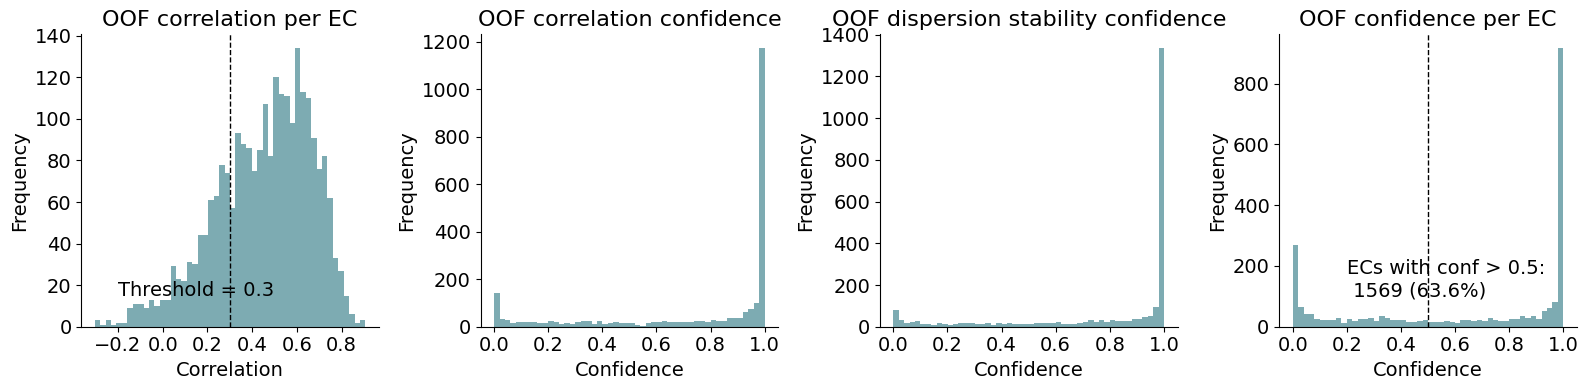

In [180]:
#plot the distribution of oof_corr and cond_disp:
plt.figure(figsize=(16,4))
plt.subplot(1,4,1)
plt.hist(S["oof_spearman"].dropna(), bins=50, color='#468892FF', edgecolor=None, alpha=0.7)
plt.xlabel("Correlation", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("OOF correlation per EC", fontsize=16)
#add the vertical lines for correlation threshold:
plt.axvline(x=threshold_r0, color='black', linestyle='--', linewidth=1)

#also add text for those lines:
plt.text(-0.2, 15, f"Threshold = {threshold_r0}", color='black', fontsize=14)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.subplot(1,4,2)
plt.hist(S["conf_corr"].dropna(), bins=50, color='#468892FF', edgecolor=None, alpha=0.7)
plt.xlabel("Confidence", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("OOF correlation confidence", fontsize=16)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.subplot(1,4,3)
plt.hist(S["conf_stab"].dropna(), bins=50, color='#468892FF', edgecolor=None, alpha=0.7)
plt.xlabel("Confidence", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("OOF dispersion stability confidence", fontsize=16)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.subplot(1,4,4)
plt.hist(S["confidence"].dropna(), bins=50, color='#468892FF', edgecolor=None, alpha=0.7)
plt.xlabel("Confidence", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("OOF confidence per EC", fontsize=16)
#calculate how many KOs have confidence > 0.5:
num_high_confidence = (S["confidence"] > 0.5).sum()
#also calculate the percentage:
percentage_high_confidence = (num_high_confidence / len(S)) * 100
#add the vertical lines for disp_low and disp_high:
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=1)
#also add text for those lines:

plt.text(0.2, 100, f"ECs with conf > 0.5:\n {num_high_confidence} ({percentage_high_confidence:.1f}%)", color='black', fontsize=14)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
#save the figure as pdf:
plt.tight_layout()
figure_path = results_dir / 'ko_confidence_distribution.pdf'
plt.savefig(figure_path, format='pdf', bbox_inches='tight')
plt.show()

## Compare against PICRUSt2 + null distributions (are kNN predictions better than predicting the average KO profile of the dataset?)
We compute the same metrics for PICRUSt2 and null distributions, and compare the results.


this will take a while ( a few mins), you can decrease null_n for speed!

In [181]:
data_cfg

{'x_full': 'X_ASVs_full.tsv',
 'x': 'X_ASVs.tsv',
 'y': 'Y_ecs.tsv',
 'picrust2': 'picrust2_ecs.tsv'}

In [182]:
# Load PICRUSt2 predictions if available and compute metrics
picrust_metrics = None
picrust = None
picrust_path = repo_root / "data/primates" / data_cfg["picrust2"]
if picrust_path.exists():
    picrust = pd.read_csv(picrust_path, sep="	", index_col=0)
    picrust_metrics = evaluate_paired_subset(
        truth_tpm=Y,
        pred_tss=picrust,
        pseudocount=float(model_cfg["pseudocount_y"]),
        detect_threshold=y_detect_threshold,
        prf_thresh=float(prf_cfg["prf_thresh"]),
        prf_weight=str(prf_cfg["prf_weight"]),
        compute_wclr=bool(metrics_cfg["compute_wclr"]),
        compute_jsd=bool(metrics_cfg["compute_jsd"]),
        compute_pathway=bool(metrics_cfg["compute_pathway_rmse"]),
        compute_per_pathway=bool(metrics_cfg["pathway_rmse_per_group"]),
        ko_to_group=None,
        log1p_pathway=bool(metrics_cfg["pathway_rmse_log1p"]),
        compute_null=True,
        null_n=50,
        null_seed=0,
        null_mean_noise_scale=0.0001, # null mean noise scale, meaning how much noise is added to the null predictions, the unit is in fraction of the mean of the true values
    )


now, we aggregate all results together for easier comparison:

In [183]:
len(Y.columns.intersection(oof_fixed_clr.columns))


2468

In [184]:
len(Y.columns.union(oof_fixed_clr.columns))

2468

In [185]:
Y

,EC:1.1.1.1,EC:1.1.1.10,EC:1.1.1.100,EC:1.1.1.103,EC:1.1.1.105,EC:1.1.1.107,EC:1.1.1.108,EC:1.1.1.11,EC:1.1.1.12,EC:1.1.1.125,...,EC:6.4.1.4,EC:6.4.1.6,EC:6.4.1.7,EC:6.4.1.8,EC:6.5.1.1,EC:6.5.1.2,EC:6.5.1.3,EC:6.5.1.4,EC:6.6.1.1,EC:6.6.1.2
11212.RC2071,882.245,0.0,806.782,267.042,3.218,3.359,0.000,0.000,1.577,32.958,...,0.000,0.0,19.163,0.0,37.990,2599.466,0.000,20.302,34.780,31.259
11212.JB34,393.862,0.0,663.437,75.725,0.000,0.000,0.000,0.000,0.000,19.723,...,0.000,0.0,12.626,0.0,47.613,1382.822,10.438,25.260,27.601,35.900
11212.ERUB.20M,737.743,0.0,656.099,20.285,0.000,0.000,0.000,5.374,2.255,20.801,...,0.000,0.0,6.015,0.0,28.404,937.360,5.747,21.316,9.543,30.463
11212.JB1,413.478,0.0,478.133,102.814,0.000,0.000,0.000,0.000,0.000,26.126,...,0.000,0.0,37.191,0.0,206.140,1638.012,84.022,55.542,32.723,54.205
11212.JB3,865.619,0.0,1425.914,170.603,0.000,0.000,0.000,0.000,0.000,47.797,...,3.979,0.0,21.317,0.0,51.575,3546.187,28.388,32.401,69.301,70.561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11212.LabEllis3,355.540,0.0,501.310,18.890,0.000,0.000,0.000,0.000,0.000,6.965,...,0.000,0.0,5.601,0.0,41.416,844.879,0.000,0.000,3.227,16.243
11212.BWC2026,513.341,0.0,310.141,118.507,1.111,0.000,0.000,0.000,1.756,13.498,...,0.000,0.0,9.218,0.0,14.980,1599.876,0.000,0.000,12.349,9.606
11212.APF38,909.542,0.0,1140.583,54.293,0.000,0.000,4.321,0.000,2.447,27.501,...,0.000,0.0,9.370,0.0,0.000,1762.959,7.155,0.000,2.892,73.502
11212.JB29,312.903,0.0,640.693,141.795,0.000,0.000,0.000,0.000,0.000,16.755,...,23.719,0.0,11.754,0.0,59.259,1682.500,4.619,6.073,1.673,2.445


In [186]:
oof_fixed_clr

,EC:1.1.1.1,EC:1.1.1.10,EC:1.1.1.100,EC:1.1.1.103,EC:1.1.1.105,EC:1.1.1.107,EC:1.1.1.108,EC:1.1.1.11,EC:1.1.1.12,EC:1.1.1.125,...,EC:6.4.1.4,EC:6.4.1.6,EC:6.4.1.7,EC:6.4.1.8,EC:6.5.1.1,EC:6.5.1.2,EC:6.5.1.3,EC:6.5.1.4,EC:6.6.1.1,EC:6.6.1.2
11212.RC2071,4.803369,-3.164202,4.920989,3.020765,-1.210919,-2.427339,-2.521693,-3.074224,-1.990375,1.428872,...,-1.978289,-3.023025,1.420329,-3.179675,1.273959,5.789743,-0.682171,-1.094026,0.847358,1.478222
11212.JB34,4.617239,-3.147636,5.006493,3.029495,-2.202654,-2.998589,-2.992757,-3.055471,-2.667556,1.220582,...,-1.691278,-3.135133,1.190573,-3.208398,1.447733,5.859639,0.296656,0.037399,0.480710,1.475338
11212.ERUB.20M,5.076363,-3.145496,5.087013,2.163021,-1.677284,-3.017498,-3.163238,-1.672700,-1.909810,1.380629,...,-2.701953,-3.237612,0.742488,-3.200990,1.575133,5.679637,-1.018727,0.717496,1.019151,2.002558
11212.JB1,4.762015,-3.105491,4.995500,2.934824,-1.728902,-2.670763,-3.052693,-3.042943,-2.589567,1.442821,...,-2.629730,-3.125314,1.564947,-3.053878,1.705776,5.845926,0.071092,0.558653,0.996577,1.602969
11212.JB3,4.620651,-3.108966,5.004115,3.081338,-2.380091,-2.829537,-2.928110,-3.105437,-2.757896,1.288767,...,-1.902352,-3.117533,1.176699,-3.105585,1.586468,5.927028,0.544478,0.129100,0.667677,1.418898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11212.LabEllis3,4.848703,-2.993928,5.181771,2.191412,-2.214126,-2.961458,-2.893326,-3.019792,-2.361714,1.131529,...,-2.769384,-3.019536,0.861413,-2.946090,0.927613,5.900594,-0.758381,-1.946559,0.117203,1.764740
11212.BWC2026,4.844012,-3.042373,4.899159,3.127264,-2.230408,-2.780229,-2.470524,-3.046738,-1.856787,1.450377,...,-2.495438,-3.061106,1.311143,-2.998959,1.109930,5.943816,-1.546994,-0.560122,0.757193,1.580255
11212.APF38,4.981034,-2.902842,5.213691,2.505972,-2.694089,-3.084482,-2.969960,-2.852418,-1.991248,1.367744,...,-2.689888,-3.024917,0.833510,-2.978538,0.338005,5.940981,-0.745409,-1.775002,-0.324495,1.750261
11212.JB29,4.607519,-3.133460,5.005673,2.908997,-2.503346,-2.869995,-3.038099,-3.123621,-2.689394,1.190098,...,-2.348820,-3.133385,1.162915,-3.142316,1.487640,5.847903,0.478305,0.132504,0.841082,1.962913


In [187]:
# Build a comparison table: intersection vs union_raw vs union_strict + null baselines
metrics_spec = [
    {"name": "dm_spearman", "intersection": "intersection_dm_spearman", "union_raw": "dm_union_raw", "union_strict": "dm_union_strict",
     "null_sample": "null_sample_dm_spearman_union_strict_mean", "null_feature": "null_feature_dm_spearman_union_strict_mean", "null_mean": "null_mean_dm_spearman_union_strict_mean"},
    {"name": "bray_spearman", "intersection": "intersection_bray_spearman", "union_raw": "bray_union_raw", "union_strict": "bray_union_strict",
     "null_sample": "null_sample_bray_spearman_union_strict_mean", "null_feature": "null_feature_bray_spearman_union_strict_mean", "null_mean": "null_mean_bray_spearman_union_strict_mean"},
    {"name": "procrustes_aitchison", "intersection": "intersection_procrustes_aitchison", "union_raw": "procrustes_aitchison_raw", "union_strict": "procrustes_aitchison_strict",
     "null_sample": "null_sample_procrustes_aitchison_union_strict_mean", "null_feature": "null_feature_procrustes_aitchison_union_strict_mean", "null_mean": "null_mean_procrustes_aitchison_union_strict_mean"},
    {"name": "procrustes_bray", "intersection": "intersection_procrustes_bray", "union_raw": "procrustes_bray_raw", "union_strict": "procrustes_bray_strict",
     "null_sample": "null_sample_procrustes_bray_union_strict_mean", "null_feature": "null_feature_procrustes_bray_union_strict_mean", "null_mean": "null_mean_procrustes_bray_union_strict_mean"},
    {"name": "sample_spearman_tss", "intersection": "sample_spearman_tss_intersection", "union_raw": "sample_spearman_tss_union_raw", "union_strict": "sample_spearman_tss_union_strict",
     "null_sample": "null_sample_sample_spearman_tss_union_strict_mean", "null_feature": "null_feature_sample_spearman_tss_union_strict_mean", "null_mean": "null_mean_sample_spearman_tss_union_strict_mean"},
    {"name": "sample_spearman_clr", "intersection": "sample_spearman_clr_intersection", "union_raw": "sample_spearman_clr_union_raw", "union_strict": "sample_spearman_clr_union_strict",
     "null_sample": "null_sample_sample_spearman_clr_union_strict_mean", "null_feature": "null_feature_sample_spearman_clr_union_strict_mean", "null_mean": "null_mean_sample_spearman_clr_union_strict_mean"},
    {"name": "soft_precision", "intersection": "intersection_soft_precision", "union_raw": "soft_precision_union_raw", "union_strict": "soft_precision",
     "null_sample": "null_sample_soft_precision_union_strict_mean", "null_feature": "null_feature_soft_precision_union_strict_mean", "null_mean": "null_mean_soft_precision_union_strict_mean"},
    {"name": "soft_recall", "intersection": "intersection_soft_recall", "union_raw": "soft_recall_union_raw", "union_strict": "soft_recall",
     "null_sample": "null_sample_soft_recall_union_strict_mean", "null_feature": "null_feature_soft_recall_union_strict_mean", "null_mean": "null_mean_soft_recall_union_strict_mean"},
    {"name": "soft_f1", "intersection": "intersection_soft_f1", "union_raw": "soft_f1_union_raw", "union_strict": "soft_f1",
     "null_sample": "null_sample_soft_f1_union_strict_mean", "null_feature": "null_feature_soft_f1_union_strict_mean", "null_mean": "null_mean_soft_f1_union_strict_mean"},
    {"name": "wclr_mse", "intersection": "intersection_wclr_mse", "union_raw": "wclr_mse_union_raw", "union_strict": "wclr_mse",
     "null_sample": "null_sample_wclr_mse_union_strict_mean", "null_feature": "null_feature_wclr_mse_union_strict_mean", "null_mean": "null_mean_wclr_mse_union_strict_mean"},
    {"name": "jsd", "intersection": "intersection_jsd", "union_raw": "jsd_union_raw", "union_strict": "jsd",
     "null_sample": "null_sample_jsd_union_strict_mean", "null_feature": "null_feature_jsd_union_strict_mean", "null_mean": "null_mean_jsd_union_strict_mean"},
    {"name": "pathway_rmse", "intersection": "intersection_pathway_rmse", "union_raw": "pathway_rmse_union_raw", "union_strict": "pathway_rmse",
     "null_sample": "null_sample_pathway_rmse_union_strict_mean", "null_feature": "null_feature_pathway_rmse_union_strict_mean", "null_mean": "null_mean_pathway_rmse_union_strict_mean"},
]


def _get(d, key):
    if d is None or key is None:
        return None
    return d.get(key)

rows = []
for spec in metrics_spec:
    name = spec["name"]
    model_inter = _get(metrics_oof, spec["intersection"])
    model_raw = _get(metrics_oof, spec["union_raw"])
    model_strict = _get(metrics_oof, spec["union_strict"])
    model_null_sample = _get(metrics_oof, spec["null_sample"])
    model_null_feature = _get(metrics_oof, spec["null_feature"])
    model_null_mean = _get(metrics_oof, spec["null_mean"])
    pic_inter = _get(picrust_metrics, spec["intersection"])
    pic_raw = _get(picrust_metrics, spec["union_raw"])
    pic_strict = _get(picrust_metrics, spec["union_strict"])
    pic_null_sample = _get(picrust_metrics, spec["null_sample"])
    pic_null_feature = _get(picrust_metrics, spec["null_feature"])
    pic_null_mean = _get(picrust_metrics, spec["null_mean"])
    rows.append({
        "metric": name,
        "model_intersection": model_inter,
        "model_union_raw": model_raw,
        "model_union_strict": model_strict,
        "model_null_sample_mean": model_null_sample,
        "model_null_feature_mean": model_null_feature,
        "model_null_mean": model_null_mean,
        "picrust_intersection": pic_inter,
        "picrust_union_raw": pic_raw,
        "picrust_union_strict": pic_strict,
        "picrust_null_sample_mean": pic_null_sample,
        "picrust_null_feature_mean": pic_null_feature,
        "picrust_null_mean": pic_null_mean,
        "delta_intersection": (None if model_inter is None or pic_inter is None else model_inter - pic_inter),
        "delta_union_raw": (None if model_raw is None or pic_raw is None else model_raw - pic_raw),
        "delta_union_strict": (None if model_strict is None or pic_strict is None else model_strict - pic_strict),
    })

compare_table = pd.DataFrame(rows)
#save the compare_table to tsv:
compare_table.to_csv(results_dir / 'comparison_table_all_metrics.tsv', sep='	', index=False)
compare_table


,metric,model_intersection,model_union_raw,model_union_strict,model_null_sample_mean,model_null_feature_mean,model_null_mean,picrust_intersection,picrust_union_raw,picrust_union_strict,picrust_null_sample_mean,picrust_null_feature_mean,picrust_null_mean,delta_intersection,delta_union_raw,delta_union_strict
0,dm_spearman,0.558163,0.558163,0.931120,0.019833,0.928792,0.673536,0.661000,0.636370,0.878948,-0.004247,0.877650,0.714177,-0.102836,-0.078206,0.052172
1,bray_spearman,0.487632,0.487632,0.872796,0.000616,0.858931,0.707923,0.633150,0.643837,0.802656,0.001191,0.791594,0.733863,-0.145517,-0.156204,0.070141
2,procrustes_aitchison,0.618597,0.618597,0.786843,0.055199,0.769055,0.533111,0.590978,0.566101,0.754831,0.056272,0.738199,0.546548,0.027620,0.052496,0.032013
3,procrustes_bray,0.567916,0.567916,0.755678,0.043409,0.691596,0.535869,0.605748,0.611957,0.675473,0.051077,0.657507,0.545963,-0.037832,-0.044041,0.080205
4,sample_spearman_tss,0.922506,0.922506,0.868482,0.610632,-0.000641,0.153158,0.761290,0.685211,0.419909,0.381755,-0.000900,0.143501,0.161216,0.237294,0.448573
5,sample_spearman_clr,0.922506,0.922506,0.868482,0.610632,-0.000641,0.153158,0.761290,0.685211,0.419909,0.381755,-0.000900,0.143501,0.161216,0.237294,0.448573
6,soft_precision,0.845472,0.845472,0.878540,0.709191,0.009472,0.610081,0.778287,0.726012,0.579690,0.542961,0.007711,0.631666,0.067185,0.119460,0.298850
7,soft_recall,0.964634,0.964634,0.865299,0.684264,0.009722,0.849325,0.892227,0.763806,0.312665,0.360956,0.003862,0.836270,0.072406,0.200828,0.552634
8,soft_f1,0.899707,0.899707,0.864475,0.560564,0.009514,0.663170,0.830306,0.743011,0.399805,0.338933,0.005097,0.674176,0.069401,0.156697,0.464669
9,wclr_mse,1.697014,1.697014,5.823664,23.821242,21.474063,15.676549,7.786870,8.552300,17.173392,20.914259,20.433478,15.006946,-6.089856,-6.855285,-11.349728


Metric definitions (higher is better unless noted):

  - dm_spearman: Spearman correlation between upper triangles of Aitchison distance matrices
    (CLR space). Measures how well sample–sample relationships are preserved.

  - bray_spearman: Spearman correlation between upper triangles of Bray–Curtis distance matrices
    (TSS space). Also measures sample–sample structure, but in Bray–Curtis space.

  - procrustes_aitchison_strict: Procrustes similarity between ordinations of Aitchison distance matrices
    (CLR space). Higher means closer geometric alignment of the two ordinations.

  - procrustes_bray_strict: Procrustes similarity between ordinations of Bray–Curtis distance matrices
    (TSS space). Higher means closer geometric alignment.

  - soft_precision / soft_recall / soft_f1: Thresholded precision/recall/F1 on KO presence,
    computed in TSS space using the chosen threshold and weighting scheme.
    - soft_precision = TP / (TP + FP), meaning of all predicted present KOs, how many are truly present.
    - soft_recall = TP / (TP + FN), meaning of all truly present KOs, how many are predicted present.
    - soft_f1 = 2 * (soft_precision * soft_recall) / (soft_precision + soft_recall) (harmonic mean of precision and recall).

  - wclr_mse: Weighted MSE in CLR space (lower is better). Weights emphasize more stable features.

  - jsd: Jensen–Shannon divergence between TSS profiles (lower is better).

  - pathway_rmse: RMSE after aggregating KOs to pathways/superclasses (lower is better).

  - model_null_sample_mean = null baseline from shuffling samples (breaks sample alignment, preserves per‑sample feature distribution).
  - model_null_feature_mean = null baseline from shuffling features (breaks feature alignment, preserves per‑feature sample distribution).
  - model_null_mean = null baseline from a mean profile + noise (global average baseline).

In [188]:
# Visualize deltas (positive = model better than PICRUSt2 for correlation metrics)
#multiply all except wclr_mse, pathway_rmse and jsd by 100 (for percentage):
compare_table_for_plotting = compare_table.copy()
#set index to metric:
compare_table_for_plotting = compare_table_for_plotting.set_index('metric')
#multiply each row except wclr_mse by 100:

for idx in compare_table_for_plotting.index:
    if idx != 'wclr_mse' and idx != 'pathway_rmse' and idx != 'jsd':
        compare_table_for_plotting.loc[idx] = compare_table_for_plotting.loc[idx]* 100

compare_table_for_plotting
        


,model_intersection,model_union_raw,model_union_strict,model_null_sample_mean,model_null_feature_mean,model_null_mean,picrust_intersection,picrust_union_raw,picrust_union_strict,picrust_null_sample_mean,picrust_null_feature_mean,picrust_null_mean,delta_intersection,delta_union_raw,delta_union_strict
metric,,,,,,,,,,,,,,,
dm_spearman,55.816349,55.816349,93.111991,1.983311,92.879201,67.353563,66.099958,63.636980,87.894753,-0.424729,87.765035,71.417691,-10.283609,-7.820631,5.217239
bray_spearman,48.763249,48.763249,87.279632,0.061623,85.893128,70.792304,63.314955,64.383653,80.265552,0.119130,79.159432,73.386332,-14.551706,-15.620404,7.014080
procrustes_aitchison,61.859727,61.859727,78.684322,5.519856,76.905542,53.311075,59.097764,56.610116,75.483063,5.627220,73.819925,54.654776,2.761963,5.249611,3.201260
procrustes_bray,56.791581,56.791581,75.567796,4.340936,69.159576,53.586924,60.574774,61.195691,67.547292,5.107697,65.750692,54.596329,-3.783193,-4.404110,8.020505
sample_spearman_tss,92.250563,92.250563,86.848182,61.063242,-0.064118,15.315809,76.129005,68.521131,41.990905,38.175513,-0.090033,14.350069,16.121558,23.729432,44.857276
sample_spearman_clr,92.250566,92.250564,86.848182,61.063242,-0.064118,15.315809,76.129010,68.521133,41.990905,38.175513,-0.090033,14.350069,16.121556,23.729431,44.857276
soft_precision,84.547204,84.547204,87.853951,70.919119,0.947247,61.008060,77.828662,72.601158,57.968981,54.296065,0.771094,63.166565,6.718542,11.946046,29.884971
soft_recall,96.463357,96.463357,86.529895,68.426413,0.972150,84.932487,89.222722,76.380570,31.266473,36.095574,0.386219,83.627043,7.240635,20.082787,55.263422
soft_f1,89.970744,89.970744,86.447463,56.056419,0.951357,66.317025,83.030648,74.301054,39.980547,33.893309,0.509749,67.417569,6.940097,15.669690,46.466916


In [189]:
#load some colors for plotting
hex_colors = ['#240E31FF', '#CB6BCEFF', '#468892FF', '#74F3D3FF',
              '#751C6DFF', '#FDC067FF', '#AC9ECEFF', '#6EC5ABFF']


In [86]:
results_dir

PosixPath('/Users/meyeanni/Desktop/git_sourdough/Intelligrate/results/primates_ecs')

now we'll compare correspondence between kNN predictability and PICRUSt2 vs. kNN improvement over PICRUSt2

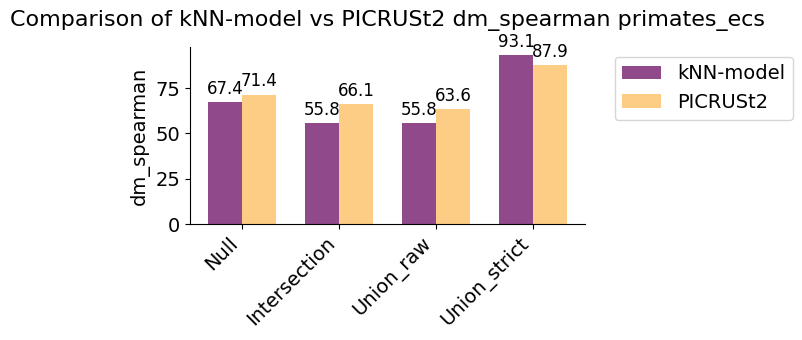

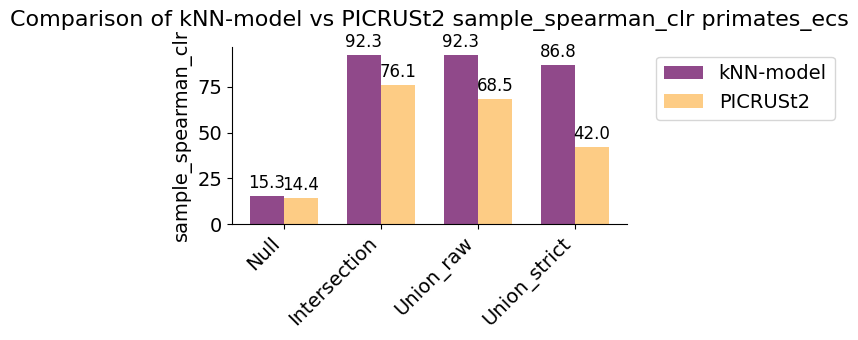

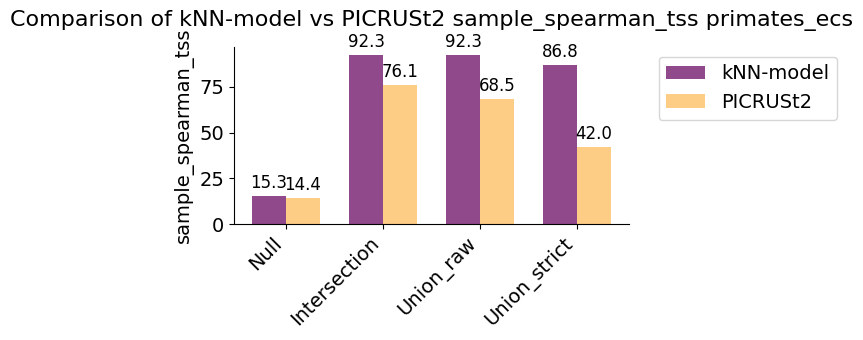

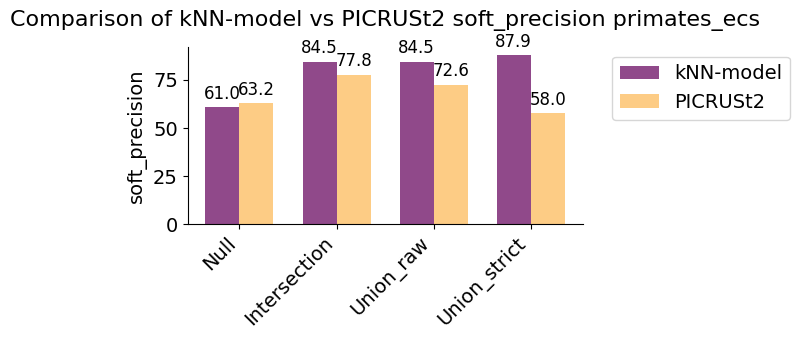

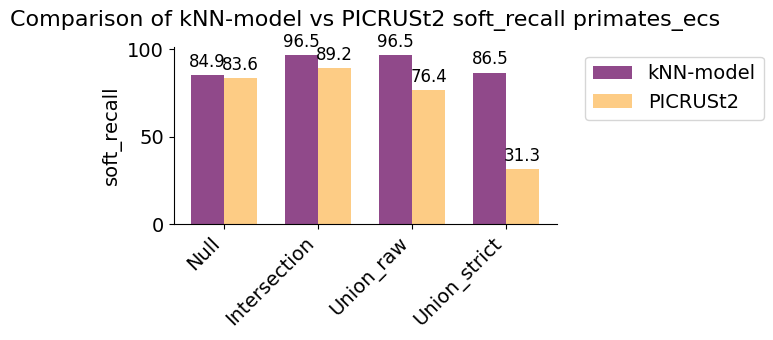

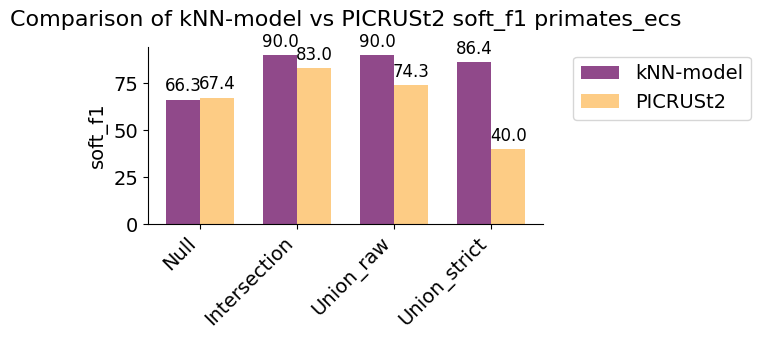

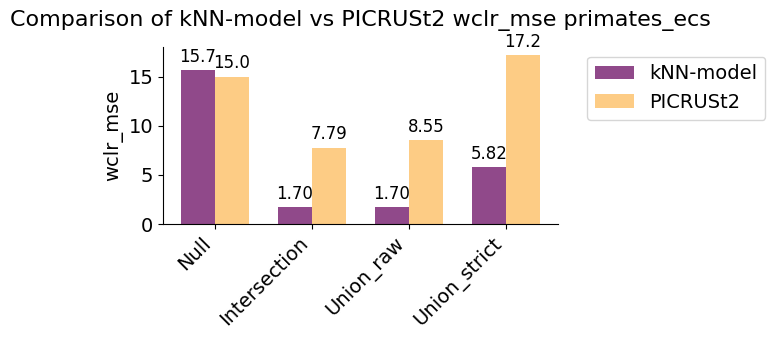

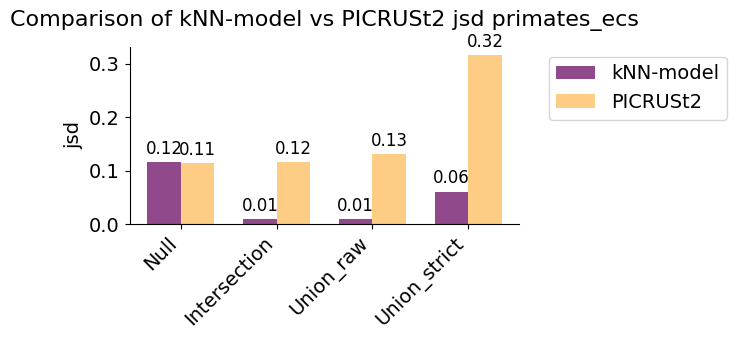

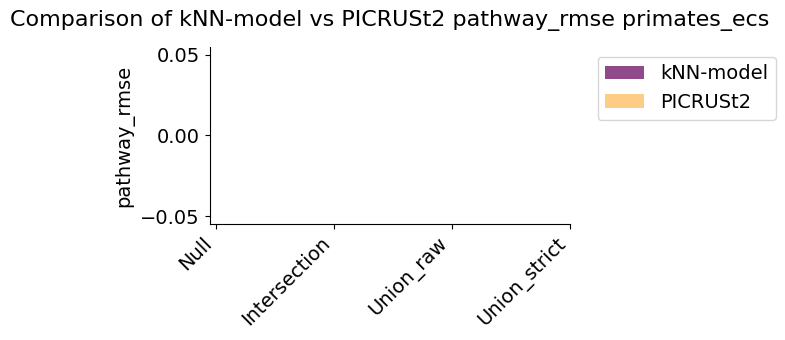

In [190]:
#make a bar plot for dm_spearman for model_intersection, model_union_raw, model_union_strict, model_null_mean, same for picrust:
import matplotlib.pyplot as plt
labels = ['Null', 'Intersection', 'Union_raw', 'Union_strict']
metrics = ['dm_spearman', 'sample_spearman_clr', 'sample_spearman_tss', 'soft_precision', 'soft_recall', 'soft_f1', 'wclr_mse', 'jsd', 'pathway_rmse']
for metric in metrics:
    model_values = [
        compare_table_for_plotting.loc[metric, 'model_null_mean'],
        compare_table_for_plotting.loc[metric, 'model_intersection'],
        compare_table_for_plotting.loc[metric, 'model_union_raw'],
        compare_table_for_plotting.loc[metric, 'model_union_strict'],
    ]
    picrust_values = [
        compare_table_for_plotting.loc[metric, 'picrust_null_mean'],
        compare_table_for_plotting.loc[metric, 'picrust_intersection'],
        compare_table_for_plotting.loc[metric, 'picrust_union_raw'],
        compare_table_for_plotting.loc[metric, 'picrust_union_strict'],
    ]
    x = range(len(labels))
    width = 0.35  # the width of the bars

    fig, ax = plt.subplots()
    #set figure size:
    fig.set_size_inches(7, 3.5)
    rects1 = ax.bar([p - width/2 for p in x], model_values, width, label='kNN-model', color=hex_colors[4], alpha=0.8)
    rects2 = ax.bar([p + width/2 for p in x], picrust_values, width, label='PICRUSt2', color=hex_colors[5], alpha=0.8)
    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel(f"{metric}", fontsize=14)
    ax.set_title(f'Comparison of kNN-model vs PICRUSt2 {metric} primates_ecs', fontsize=16, pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=14, rotation=45, ha='right')
    #set y tick labels also to fontsize 14:
    ax.tick_params(axis='y', labelsize=14)
    ax.legend(fontsize=14, frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')
    #add the values on top of the bars:
    def autolabel(rects):
        """Attach a text label above each bar in *rects*, displaying its height."""
        for rect in rects:
            height = rect.get_height()
            if height > 10:
                ax.annotate(f'{height:.1f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),  # 3 points vertical offset
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=12)
            else:
                ax.annotate(f'{height:.2f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),  # 3 points vertical offset
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=12)
  

    autolabel(rects1)
    autolabel(rects2)
    #despine:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.tight_layout()
    #save the figure as pdf:
    figure_path = results_dir / f'comparison_kNN_picrust2_{metric}.pdf'
    plt.savefig(figure_path, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()

### Next: Sample-wise Spearman correlations (truth vs prediction) with null baselines
This shows per-sample correlations across KOs in TSS and CLR space, plus null baselines from shuffled samples and shuffled features.


In [191]:
from intelligrate.extrapolate.metrics import (
      _pairwise_union_mats_tss,
      _pairwise_intersection_mats_tss,
      samplewise_spearman,
  )
from intelligrate.extrapolate.transforms import clr_rows
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _sample_spearman_dist(truth_tpm, pred_tss, *, pseudocount, detect_threshold, mode="union_strict"):
      if mode == "intersection":
          truth_tss, pred_tss = _pairwise_intersection_mats_tss(truth_tpm, pred_tss, detect_threshold=0.0)
      elif mode == "union_raw":
          truth_tss, pred_tss = _pairwise_union_mats_tss(truth_tpm, pred_tss, detect_threshold=0.0, fillna_zero=True)
      else:  # union_strict
          truth_tss, pred_tss = _pairwise_union_mats_tss(truth_tpm, pred_tss, detect_threshold=detect_threshold, fillna_zero=True)

      truth_clr = clr_rows(truth_tss, pseudocount=pseudocount)
      pred_clr = clr_rows(pred_tss, pseudocount=pseudocount)
      good = truth_clr.notna().all(axis=1) & pred_clr.notna().all(axis=1)
      truth_tss, pred_tss = truth_tss.loc[good], pred_tss.loc[good]
      truth_clr, pred_clr = truth_clr.loc[good], pred_clr.loc[good]

      tss = samplewise_spearman(truth_tss, pred_tss)
      clr = samplewise_spearman(truth_clr, pred_clr)
      return tss, clr

def _null_sample_spearman_dist(truth_tpm, pred_tss, *, pseudocount, detect_threshold, n=50, seed=0):
      rng = np.random.default_rng(seed)
      truth_tss, pred_tss = _pairwise_union_mats_tss(truth_tpm, pred_tss, detect_threshold=detect_threshold, fillna_zero=True)
      truth_clr = clr_rows(truth_tss, pseudocount=pseudocount)
      pred_clr = clr_rows(pred_tss, pseudocount=pseudocount)
      good = truth_clr.notna().all(axis=1) & pred_clr.notna().all(axis=1)
      truth_tss, pred_tss = truth_tss.loc[good], pred_tss.loc[good]
      truth_clr, pred_clr = truth_clr.loc[good], pred_clr.loc[good]

      pred_tss_arr = pred_tss.to_numpy(float)
      pred_clr_arr = pred_clr.to_numpy(float)
      tss_vals, clr_vals = [], []
      for _ in range(int(n)):
          perm = rng.permutation(pred_tss_arr.shape[0])
          pred_tss_perm = pd.DataFrame(pred_tss_arr[perm, :], index=truth_tss.index, columns=truth_tss.columns)
          pred_clr_perm = pd.DataFrame(pred_clr_arr[perm, :], index=truth_clr.index, columns=truth_clr.columns)
          tss_vals.append(samplewise_spearman(truth_tss, pred_tss_perm))
          clr_vals.append(samplewise_spearman(truth_clr, pred_clr_perm))
      return pd.concat(tss_vals, axis=0), pd.concat(clr_vals, axis=0)

def _null_feature_spearman_dist(truth_tpm, pred_tss, *, pseudocount, detect_threshold, n=50, seed=1):
      rng = np.random.default_rng(seed)
      truth_tss, pred_tss = _pairwise_union_mats_tss(truth_tpm, pred_tss, detect_threshold=detect_threshold, fillna_zero=True)
      truth_clr = clr_rows(truth_tss, pseudocount=pseudocount)
      pred_clr = clr_rows(pred_tss, pseudocount=pseudocount)
      good = truth_clr.notna().all(axis=1) & pred_clr.notna().all(axis=1)
      truth_tss, pred_tss = truth_tss.loc[good], pred_tss.loc[good]
      truth_clr, pred_clr = truth_clr.loc[good], pred_clr.loc[good]

      pred_tss_arr = pred_tss.to_numpy(float)
      pred_clr_arr = pred_clr.to_numpy(float)
      tss_vals, clr_vals = [], []
      for _ in range(int(n)):
          perm = rng.permutation(pred_tss_arr.shape[1])
          pred_tss_feat = pd.DataFrame(pred_tss_arr[:, perm], index=truth_tss.index, columns=truth_tss.columns)
          pred_clr_feat = pd.DataFrame(pred_clr_arr[:, perm], index=truth_clr.index, columns=truth_clr.columns)
          tss_vals.append(samplewise_spearman(truth_tss, pred_tss_feat))
          clr_vals.append(samplewise_spearman(truth_clr, pred_clr_feat))
      return pd.concat(tss_vals, axis=0), pd.concat(clr_vals, axis=0)

def _null_mean_spearman_dist(truth_tpm, pred_tss, *, pseudocount, detect_threshold, n=50, seed=2, noise=0.01):
      rng = np.random.default_rng(seed)
      truth_tss, pred_tss = _pairwise_union_mats_tss(truth_tpm, pred_tss, detect_threshold=detect_threshold, fillna_zero=True)
      truth_clr = clr_rows(truth_tss, pseudocount=pseudocount)
      pred_clr = clr_rows(pred_tss, pseudocount=pseudocount)
      good = truth_clr.notna().all(axis=1) & pred_clr.notna().all(axis=1)
      truth_tss, pred_tss = truth_tss.loc[good], pred_tss.loc[good]
      truth_clr, pred_clr = truth_clr.loc[good], pred_clr.loc[good]

      mu_tss = truth_tss.mean(axis=0).to_numpy(float)
      mu_clr = truth_clr.mean(axis=0).to_numpy(float)
      tss_vals, clr_vals = [], []
      for _ in range(int(n)):
          noise_tss = rng.normal(0.0, noise, size=pred_tss.shape)
          noise_clr = rng.normal(0.0, noise, size=pred_clr.shape)
          pred_tss_mean = pd.DataFrame(np.clip(mu_tss[None, :] + noise_tss, 0.0, None), index=truth_tss.index, columns=truth_tss.columns)
          pred_clr_mean = pd.DataFrame(mu_clr[None, :] + noise_clr, index=truth_clr.index, columns=truth_clr.columns)
          tss_vals.append(samplewise_spearman(truth_tss, pred_tss_mean))
          clr_vals.append(samplewise_spearman(truth_clr, pred_clr_mean))
      return pd.concat(tss_vals, axis=0), pd.concat(clr_vals, axis=0)

  # --- Compute distributions for strict / raw / intersection ---
tss_model, clr_model = _sample_spearman_dist(Y, oof_fixed_tss_aligned, pseudocount=model_cfg["pseudocount_y"], detect_threshold=y_detect_threshold,
  mode="union_strict")
tss_model_raw, clr_model_raw = _sample_spearman_dist(Y, oof_fixed_tss_aligned, pseudocount=model_cfg["pseudocount_y"], detect_threshold=y_detect_threshold,
  mode="union_raw")
tss_model_int, clr_model_int = _sample_spearman_dist(Y, oof_fixed_tss_aligned, pseudocount=model_cfg["pseudocount_y"], detect_threshold=y_detect_threshold,
  mode="intersection")

tss_null, clr_null = _null_sample_spearman_dist(Y, oof_fixed_tss_aligned, pseudocount=model_cfg["pseudocount_y"], detect_threshold=y_detect_threshold, n=50,
  seed=0)
tss_feat_null, clr_feat_null = _null_feature_spearman_dist(Y, oof_fixed_tss_aligned, pseudocount=model_cfg["pseudocount_y"], detect_threshold=y_detect_threshold,
  n=50, seed=0)
tss_mean_null, clr_mean_null = _null_mean_spearman_dist(Y, oof_fixed_tss_aligned, pseudocount=model_cfg["pseudocount_y"], detect_threshold=y_detect_threshold,
  n=50, seed=0, noise=0.0001)

tss_pic = clr_pic = None
if picrust_metrics is not None:
      tss_pic, clr_pic = _sample_spearman_dist(Y, picrust, pseudocount=model_cfg["pseudocount_y"], detect_threshold=y_detect_threshold, mode="union_strict")
      #also for raw and intersection:
      tss_pic_raw, clr_pic_raw = _sample_spearman_dist(Y, picrust, pseudocount=model_cfg["pseudocount_y"], detect_threshold=y_detect_threshold, mode="union_raw")
      tss_pic_int, clr_pic_int = _sample_spearman_dist(Y, picrust, pseudocount=model_cfg["pseudocount_y"], detect_threshold=y_detect_threshold, mode="intersection")

      #and also nulls for picrust:
      tss_pic_null, clr_pic_null = _null_mean_spearman_dist(Y, picrust, pseudocount=model_cfg["pseudocount_y"], detect_threshold=y_detect_threshold, n=50,
        seed=0, noise=0.0001)
      



In [192]:
#now, we aggregate all the metrics to plot the distributions:

tss_map = {
      "kNN_strict": tss_model,
      "kNN_raw": tss_model_raw,
      "kNN_intersection": tss_model_int,
      # "null_sample": tss_null,
      # "null_feature": tss_feat_null,
      "kNN_null_mean": tss_mean_null,
  }
if tss_pic is not None:
      tss_map["picrust2_strict"] = tss_pic
      tss_map['picrust2_raw'] = tss_pic_raw
      tss_map['picrust2_intersection'] = tss_pic_int
      tss_map['picrust2_null_mean'] = tss_pic_null

clr_map = {
      "kNN_strict": clr_model,
      "kNN_raw": clr_model_raw,
      "kNN_intersection": clr_model_int,
      # "null_sample": clr_null,
      # "null_feature": clr_feat_null,
      "kNN_null_mean": clr_mean_null,
  }
if clr_pic is not None:
      clr_map["picrust2_strict"] = clr_pic
      clr_map['picrust2_raw'] = clr_pic_raw
      clr_map['picrust2_intersection'] = clr_pic_int
      clr_map['picrust2_null_mean'] = clr_pic_null

#rearrange the order to plot:
map_order = [
      "kNN_null_mean",
      "picrust2_null_mean",
      "kNN_intersection",
      "picrust2_intersection",
      "kNN_raw",
      "picrust2_raw",
      "kNN_strict",
      "picrust2_strict",
  ]  
tss_map = {k: tss_map[k] for k in map_order if k in tss_map}
clr_map = {k: clr_map[k] for k in map_order if k in clr_map}          


define all the plotting utilities:

/Users/meyeanni/miniconda3/envs/network-viz/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


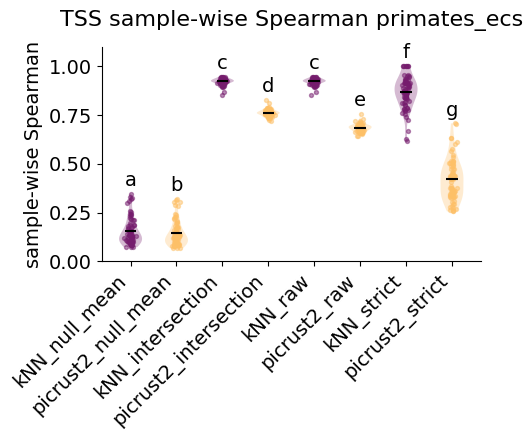

/Users/meyeanni/miniconda3/envs/network-viz/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


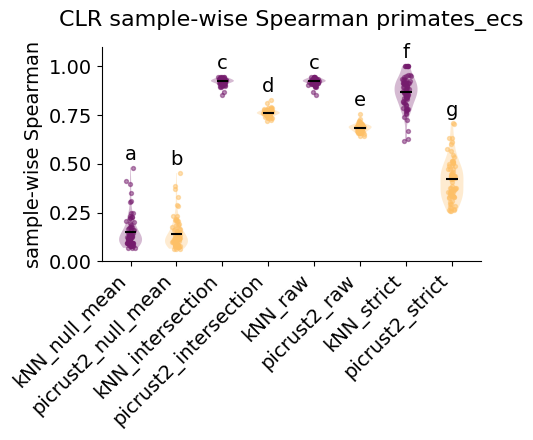

In [193]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from itertools import combinations

def pairwise_wilcoxon_cld(data_map, alpha=0.05, zero_method="wilcox"):
      """
      Paired Wilcoxon signed-rank with BH correction + CLD.
      data_map: dict[label -> pd.Series with SAME index].
      """
      labels = list(data_map.keys())
      # align indices
      common = None
      for k, v in data_map.items():
          if common is None:
              common = v.index
          else:
              common = common.intersection(v.index)
      aligned = {k: data_map[k].loc[common].astype(float) for k in labels}

      rows = []
      for a, b in combinations(labels, 2):
          x, y = aligned[a], aligned[b]
          # drop NaNs pairwise
          m = np.isfinite(x) & np.isfinite(y)
          if m.sum() < 10:
              p = np.nan
          else:
              p = wilcoxon(x[m], y[m], zero_method=zero_method).pvalue
          rows.append((a, b, p))
      p_df = pd.DataFrame(rows, columns=["A", "B", "pval"])

      # FDR correction
      pvals = p_df["pval"].to_numpy()
      mask = np.isfinite(pvals)
      adj = np.full_like(pvals, np.nan, dtype=float)
      if mask.sum() > 0:
          adj[mask] = multipletests(pvals[mask], alpha=alpha, method="fdr_bh")[1]
      p_df["p_adj"] = adj

      # significance matrix
      sig = {a: {b: False for b in labels} for a in labels}
      for _, row in p_df.iterrows():
          if np.isfinite(row["p_adj"]) and row["p_adj"] < alpha:
              sig[row["A"]][row["B"]] = True
              sig[row["B"]][row["A"]] = True

      # greedy CLD
      cld = {k: "" for k in labels}
      letters = []
      for label in labels:
          placed = False
          for letter in letters:
              conflict = False
              for other, ltr in cld.items():
                  if ltr == letter and sig[label][other]:
                      conflict = True
                      break
              if not conflict:
                  cld[label] = letter
                  placed = True
                  break
          if not placed:
              new_letter = chr(ord("a") + len(letters))
              letters.append(new_letter)
              cld[label] = new_letter

      return cld, p_df
def to_sample_mean(v, sample_index, sample_col="sample", value_col="value"):
    if isinstance(v, pd.Series):
        # if Series is already sample-indexed (possibly with repeats), groupby works too
        s = pd.to_numeric(v, errors="coerce")
        out = s.groupby(level=0).mean()
        return out.reindex(sample_index)

    if isinstance(v, pd.DataFrame):
        if sample_col in v.columns and value_col in v.columns:
            out = v.groupby(sample_col, as_index=True)[value_col].mean()
            return out.reindex(sample_index)

        # If it is wide (index=samples, columns=replicates), average across columns
        if v.index.equals(sample_index):
            return v.apply(pd.to_numeric, errors="coerce").mean(axis=1)

    raise ValueError("Cannot compute per-sample mean: no sample IDs found.")
  
sample_index = tss_model.index

tss_map_aligned = {}
for k, v in tss_map.items():
    if v is None:
        continue
    tss_map_aligned[k] = to_sample_mean(v, sample_index, sample_col="sample", value_col="spearman")

clr_map_aligned = {}
for k, v in clr_map.items():
    if v is None:
        continue
    clr_map_aligned[k] = to_sample_mean(v, sample_index, sample_col="sample", value_col="spearman")


def _plot_violin_with_cld_paired(
      data_map,
      title,
      alpha=0.05,
      colors=None,   # dict label -> color
      dot_alpha=0.5,
      letter_offset=0.02,
  ):
      labels = list(data_map.keys())
      data = [data_map[k].dropna().to_numpy(float) for k in labels]

      fig, ax = plt.subplots(figsize=(5, 4.5))
      parts = ax.violinplot(data, showmeans=True, showextrema=False)

      for i, body in enumerate(parts['bodies']):
                label = labels[i]
                c = colors.get(label, "#999999") if colors else "#999999"
                body.set_facecolor(c)
                body.set_edgecolor("none")
                body.set_alpha(0.3)

      # Set color black for mean lines:
      if 'cmeans' in parts:
          parts['cmeans'].set_color('black')
          parts['cmeans'].set_linewidth(1.5)

        # Dots with matching color
      for i, vals in enumerate(data, start=1):
            label = labels[i-1]
            c = colors.get(label, "#666666") if colors else "#666666"
            x = np.random.normal(i, 0.04, size=len(vals))
            ax.scatter(x, vals, s=8, alpha=dot_alpha, color=c)

      ax.set_xticks(range(1, len(labels) + 1))
      ax.set_xticklabels(labels, rotation=45, fontsize=14, ha='right')
      ax.tick_params(axis='y', labelsize=14)
      ax.set_ylabel("sample-wise Spearman", fontsize=14)
      ax.set_ylim(0.0, 1.1)
      ax.set_title(title, pad=15, fontsize=16)

      cld, p_df = pairwise_wilcoxon_cld(data_map, alpha=alpha)

      # Place CLD letters right above each violin
      for i, lab in enumerate(labels, start=1):
          vals = data[i-1]
          if len(vals) == 0:
              continue
          y = np.nanmax(vals) + letter_offset
          ax.text(i, y, cld.get(lab, ""), ha="center", va="bottom", fontsize=14)
      #despine:
      ax.spines['top'].set_visible(False)
      ax.spines['right'].set_visible(False)  
      fig.tight_layout()
      #save as pdf, with title in name:
      figure_path = results_dir / f'violin_{title.replace(" ", "_").lower()}.pdf'
      plt.savefig(figure_path, format='pdf', bbox_inches='tight', dpi=300)
      plt.show()
      return cld, p_df

  #Example color mapping (distinct model vs picrust):

colors = {
      "kNN_strict": hex_colors[4],
      "kNN_raw": hex_colors[4],
      "kNN_intersection": hex_colors[4],
      "picrust2_strict": hex_colors[5],
      "picrust2_raw": hex_colors[5],
      "picrust2_intersection": hex_colors[5],
      "kNN_null_mean": hex_colors[4],
      "picrust2_null_mean": hex_colors[5],
  }

cld_tss, p_tss = _plot_violin_with_cld_paired(tss_map_aligned, "TSS sample-wise Spearman primates_ecs",
  colors=colors)
cld_clr, p_clr = _plot_violin_with_cld_paired(clr_map_aligned, "CLR sample-wise Spearman primates_ecs",
  colors=colors)

## Interpreting outputs
- `results/oof_clr.tsv`, `results/oof_tss.tsv`: out-of-fold predictions from nested CV
- `results/folds.tsv`: per-fold metrics + selected hyperparameters
- `results/summary.json` / `results/summary.tsv`: overall metrics
- `results/embed.joblib`: fitted embedding for k-mers
- `results/model.joblib`: final model artifact
- `results/pred_full.*`: predictions for all samples
- `results/pred_paired.metrics.tsv`: metrics when truth is provided
